# TimesFM (Foundation Model) Testing

Notebooks 5, 7 and 8 **train** models on this series. This notebook tests **TimesFM**, a
pretrained time-series *foundation model* from Google Research: a decoder-only transformer trained
on a very large corpus of real and synthetic series, which forecasts a new series **zero-shot**,
without any training on it. The model only reads a *context* (the recent history) and continues
it.

With no weights to fit, what can still be chosen is **what the model reads**:

| Choice | Options |
|---|---|
| **Context window** ("training" cut) | all history, the last 14 / 12 / 10 / 8 / 6 / 4 years, post-COVID (as in notebooks 5 and 7) |
| **COVID rows** | `keep`, `remove` 2020–2022 (as in notebook 7), or `mask` the pandemic months as missing |
| **Target processing** | `none`, `log`, `seasonal_log_diff` |
| **Auxiliary features** (covariates) | none, calendar, COVID flags, calendar + COVID flags |
| **Symmetric averaging** | off / on (an inference option of the model) |

TimesFM is used on the **aggregated series only** (the total monthly arrivals of notebooks 5 and
7), not as a global model on the panel of notebook 8.

The protocol is the one of notebooks 5, 7 and 8, so the results are directly comparable: the same
four validation origins, the **mean seasonal MASE** over them as the selection metric, the same
baselines, MLflow logging (`eval_split = validation`) and p95 heatmaps. The test set is never read
here. TimesFM also returns **quantiles**, so the 80% forecast interval is evaluated too.

## Setup

In [1]:
import itertools
import logging
import os
import sys
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from sklearn.metrics import r2_score
from timesfm3 import TimesFM3Forecaster
from tqdm import tqdm

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

TARGET = 'arrival_count'
FREQ = 'ME'
SEASONAL_PERIOD = 12

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
EXPERIMENT_NAME = 'Brazil Tourism Forecasting TimesFM'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

### The Model and What It Supports

> Das, A., Kong, W., Sen, R. & Zhou, Y. *A decoder-only foundation model for time-series
> forecasting*. ICML 2024 — [arXiv:2310.10688](https://arxiv.org/abs/2310.10688);
> code and weights: [google-research/timesfm](https://github.com/google-research/timesfm)
> (code Apache-2.0).

The notebook uses **TimesFM 3.0** (`google/timesfm-3.0-pytorch`, package `timesfm[torch]`, module
`timesfm3`), the latest release (August 2026). Its pretrained weights are distributed under the
`timesfm-non-commercial-license-v1.0`: research and non-commercial use only, which covers this
thesis. TimesFM 2.5 (Apache-2.0 weights) would be the choice for a commercial deployment.

What the model supports, and how each capability is used here:

| Capability (`TimesFM3Forecaster.predict`) | Used here |
|---|---|
| Univariate forecasting from a context of up to 15,360 points | ✓ the total series; the context length is the "training cut" |
| **Past-and-future covariates** (`past_future_covariates`): numeric series known over the context **and** the horizon | ✓ calendar terms and COVID flags, known in advance for any month |
| Past-only covariates (`past_only_covariates`): numeric series known only over the context | ✗ they would be other observed series (e.g. the components of notebook 8); the aggregated-only scope leaves them out |
| Multivariate targets (up to 32 jointly forecast series) | ✗ same reason (notebook 8's panel) |
| Missing values (`NaN`) in the context, linearly interpolated inside the model | ✓ the `mask` COVID option |
| Quantiles 0.1 … 0.9 (`return_quantiles=True`); the point forecast is the median | ✓ the 80% interval (0.1–0.9) is scored |
| `use_symmetric_averaging`: also forecasts the sign-flipped series and averages the two | ✓ grid option |
| `make_positive`: clamps the forecast at zero | ✓ always on for arrivals on the original scale |
| `use_znorm`: z-normalizes each series before the model | ✗ the model already normalizes its input internally; on this series it gave identical forecasts |

Covariates are numeric only; the categorical month is passed as its sine and cosine.

The model runs on the CPU in a fraction of a second per forecast, so the whole grid runs
sequentially in one process (no parallel workers, which would each load their own copy of the
model).

In [2]:
MODEL_ID = 'google/timesfm-3.0-pytorch'
HORIZON = 12

model = TimesFM3Forecaster.from_pretrained(MODEL_ID)
QUANTILES = list(model.config.quantiles)
Q_LOW, Q_HIGH = QUANTILES.index(0.1), QUANTILES.index(0.9)
print(
    f'{MODEL_ID} on {model.device} | max context {model.global_context:,} | '
    f'quantiles {QUANTILES}'
)

google/timesfm-3.0-pytorch on cpu | max context 15,360 | quantiles [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [3]:
# Book helper credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.forecasting.ml_forecasting import calculate_metrics  # noqa: E402

## 1. Data and Validation Origins

Monthly totals from `train.parquet` and `val.parquet` (the test set is never read), and the same
validation origins as notebooks 5, 7 and 8: the end of training (its window is `val.parquet`) and
one year earlier, plus the two most recent yearly origins whose 12-month window ends before the
pandemic. They are counted back from the end of training, so they roll forward with the data.
At each origin the model only reads the history up to that origin.

In [4]:
def load_monthly(file_name):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    return raw.set_index('date')[TARGET].resample(FREQ).sum()


train_series = load_monthly('train.parquet')
val_series = load_monthly('val.parquet')
TRAIN_END = train_series.index[-1]
assert val_series.index[0] == TRAIN_END + pd.offsets.MonthEnd(1)
assert len(val_series) == HORIZON
# train + validation: every origin is cut from this history (never the test set)
full_series = pd.concat([train_series, val_series])

N_PRE_COVID_ORIGINS = 2
N_POST_COVID_ORIGINS = 2


def validation_window(origin):
    """First and last month forecast from `origin` (the last month the model sees)."""
    return origin + pd.offsets.MonthEnd(1), origin + pd.offsets.MonthEnd(HORIZON)


candidates = [TRAIN_END] + [
    TRAIN_END - pd.offsets.MonthEnd(12 * k) for k in range(1, len(train_series) // 12)
]
post_covid_origins = [o for o in candidates if validation_window(o)[0] > COVID_END][
    :N_POST_COVID_ORIGINS
]
pre_covid_origins = [o for o in candidates if validation_window(o)[1] < COVID_START][
    :N_PRE_COVID_ORIGINS
]
ORIGINS = sorted(pre_covid_origins + post_covid_origins)
LATEST_ORIGIN = TRAIN_END  # its validation window is val.parquet
assert LATEST_ORIGIN in ORIGINS


def origin_label(origin):
    return f'{origin:%Y-%m}'


def val_actual_at(origin):
    start, end = validation_window(origin)
    return full_series.loc[start:end]


pd.DataFrame([
    {
        'origin': origin_label(origin),
        'phase': 'pre-COVID' if origin < COVID_START else 'post-COVID',
        'validation window': f'{start:%b %Y} → {end:%b %Y}',
        'history months': len(full_series.loc[:origin]),
    }
    for origin in ORIGINS
    for start, end in [validation_window(origin)]
])

,origin,phase,validation window,history months
0,2017-08,pre-COVID,Sep 2017 → Aug 2018,344
1,2018-08,pre-COVID,Sep 2018 → Aug 2019,356
2,2023-08,post-COVID,Sep 2023 → Aug 2024,416
3,2024-08,post-COVID,Sep 2024 → Aug 2025,428


## 2. Building the Context

A zero-shot model is steered only through its input. Each configuration turns the history of
one origin into a context in four steps:

1. **Context window** (the "training" cut of the other notebooks): the last N years before the
   origin, all history, or January 2022 onwards (`post_covid`).
2. **COVID rows.**
   - `keep`: the series as it is.
   - `remove`: the years 2020–2022 are cut out and December 2019 is followed by January 2023 (three
     full years, so the months stay aligned; notebook 7).
   - `mask`: the pandemic and rebound months (April 2020 – December 2022) stay in place as
     **missing values**; TimesFM interpolates them linearly. The calendar positions are kept and the
     model sees no collapse. The mask is applied **after** the target processing, so the seasonal
     difference of 2023 is still computed from real 2022 values.

   Before the pandemic there is nothing to remove or mask, so at the pre-COVID origins both are
   the same as `keep`. `post_covid` only runs with `keep`.
3. **Target processing**, fitted on the context:

   | Option | Transform | Inverse |
   |---|---|---|
   | `none` | identity | identity (forecast clamped at zero) |
   | `log` | `log(y)` | `exp(ŷ)` |
   | `seasonal_log_diff` | `log(y_t) − log(y_{t−12})`, the yearly growth (notebook 7) | `y_{t−12} · exp(ẑ_t)` |

   TimesFM normalizes its input internally, so the transformations are not about scale; they test
   whether the model forecasts the **level**, the **log level** or the **growth rate** better.
   The quantiles are inverse-transformed the same way (all three are monotonic).
4. **Covariates** (past-and-future, next section).

In [5]:
WINDOWS = {
    'all': None,
    **{f'last_{years}y': years for years in [14, 12, 10, 8, 6, 4]},
    'post_covid': POST_COVID_START,
}
COVID_ROWS = ['keep', 'remove', 'mask']
REMOVED = (pd.Timestamp('2020-01-31'), pd.Timestamp('2022-12-31'))  # three full years
MASKED = (COVID_START, pd.Timestamp('2022-12-31'))  # pandemic and rebound
TARGET_TRANSFORMS = ['none', 'log', 'seasonal_log_diff']


def window_start(window, origin):
    spec = WINDOWS[window]
    if spec is None:
        return full_series.index[0]
    if isinstance(spec, pd.Timestamp):
        return spec
    return origin - pd.DateOffset(years=spec)


def window_exists(window, origin):
    spec = WINDOWS[window]
    return not isinstance(spec, pd.Timestamp) or origin > spec


def effective_covid_rows(covid_rows, origin):
    """Before the pandemic there is nothing to remove or mask."""
    return 'keep' if origin < REMOVED[0] else covid_rows


class SeasonalLogDiffTarget:
    """z_t = log(y_t) - log(y_{t-12}), positional; inverse from the last 12 months."""

    def __init__(self, history, period=SEASONAL_PERIOD):
        self.period = period
        self.log_history = np.log(history.astype(float)).to_numpy()
        self.last_date = history.index[-1]

    def transform(self, y):
        log_y = np.log(y.astype(float))
        return log_y - log_y.shift(self.period)

    def inverse_transform(self, z, dates):
        dates = pd.DatetimeIndex(dates)
        steps = (dates.year - self.last_date.year) * 12 + (
            dates.month - self.last_date.month
        )
        assert ((steps >= 1) & (steps <= self.period)).all(), 'up to one season ahead'
        base = self.log_history[len(self.log_history) - self.period + steps - 1]
        # z may be (horizon,) or (horizon, n_quantiles)
        return np.exp(
            np.asarray(z, dtype=float) + base.reshape(-1, *([1] * (np.ndim(z) - 1)))
        )


def make_context(window, covid_rows, transform, origin):
    """Context values (model scale, NaN where masked) and the fitted inverse."""
    history = full_series.loc[window_start(window, origin) : origin]
    if covid_rows == 'remove':
        history = history[~history.index.to_series().between(*REMOVED).to_numpy()]
    if transform == 'log':
        values = np.log(history.astype(float))
        inverse = lambda z, dates: np.exp(np.asarray(z, dtype=float))  # noqa: E731
    elif transform == 'seasonal_log_diff':
        target = SeasonalLogDiffTarget(history)
        values = target.transform(history).iloc[SEASONAL_PERIOD:]
        inverse = target.inverse_transform
    else:
        values = history.astype(float)
        inverse = lambda z, dates: np.asarray(z, dtype=float)  # noqa: E731
    if covid_rows == 'mask':
        values = values.where(~values.index.to_series().between(*MASKED))
    return values, inverse


example_origin = post_covid_origins[0]
example = pd.DataFrame({
    covid_rows: make_context('last_6y', covid_rows, 'log', example_origin)[0]
    for covid_rows in COVID_ROWS
})
print(f'Context last_6y, log, origin {origin_label(example_origin)}, per COVID option')
display(example.notna().sum().rename('non-missing months'))
example.loc['2019-10-31':'2023-03-31'].round(2)

Context last_6y, log, origin 2024-08, per COVID option


keep      73
remove    37
mask      40
Name: non-missing months, dtype: int64

,keep,remove,mask
date,,,
2019-10-31,12.93,12.93,12.93
2019-11-30,13.06,13.06,13.06
2019-12-31,13.39,13.39,13.39
2020-01-31,13.68,NaN,13.68
2020-02-29,13.61,NaN,13.61
2020-03-31,12.58,NaN,12.58
2020-04-30,6.33,NaN,NaN
2020-05-31,6.25,NaN,NaN
2020-06-30,6.48,NaN,NaN


## 3. Auxiliary Features (Past-and-Future Covariates)

TimesFM 3.0 reads numeric covariates alongside the target. A **past-and-future** covariate must be
known over the context **and** the 12 forecast months, which is the case for features derived from
the calendar:

| Option | Covariates (one row each) |
|---|---|
| `none` | — |
| `calendar` | `sin(2π·month/12)`, `cos(2π·month/12)` and the number of days in the month (centred) |
| `covid` | `is_covid` (April 2020 – December 2021) and `is_covid_recovery` (January – June 2022), the flags of notebooks 5–7 |
| `calendar+covid` | both |

- The **calendar** terms tell the model where each month sits in the year. A seasonal series
  already carries this in its own shape; the grid tests whether spelling it out helps.
- The **COVID flags** tell the model that the 2020–2022 values are exceptional, the same role as
  the exogenous regressors of SARIMAX (notebook 5). They only make sense with `keep`: with
  `remove` those months are gone and with `mask` they are missing, so the flags would carry no
  information. At the pre-COVID origins the flags are all zero, so `covid` is the same as `none`
  and `calendar+covid` the same as `calendar` there (computed once).

Features derived from the target itself (lags, rolling means, growth) are not added: the model
reads the whole target context and builds such summaries internally.

In [6]:
COVARIATES = ['none', 'calendar', 'covid', 'calendar+covid']
MEAN_DAYS_IN_MONTH = 365.25 / 12


def effective_covariates(covariates, origin):
    """Before the pandemic the COVID flags are all zero: drop them."""
    if origin >= COVID_START:
        return covariates
    return {'covid': 'none', 'calendar+covid': 'calendar'}.get(covariates, covariates)


def make_covariates(covariates, context_dates, future_dates):
    """Past-and-future covariates, shape (n_covariates, context + horizon), or None."""
    if covariates == 'none':
        return None
    dates = pd.DatetimeIndex(context_dates).append(pd.DatetimeIndex(future_dates))
    dates_series = dates.to_series()
    rows = []
    if 'calendar' in covariates:
        month = dates.month.to_numpy()
        rows += [
            np.sin(2 * np.pi * month / 12),
            np.cos(2 * np.pi * month / 12),
            dates.days_in_month.to_numpy() - MEAN_DAYS_IN_MONTH,
        ]
    if 'covid' in covariates:
        rows += [
            dates_series.between(COVID_START, COVID_END).to_numpy(),
            dates_series.between(POST_COVID_START, COVID_RECOVERY_END).to_numpy(),
        ]
    return np.asarray(rows, dtype=np.float32)


context, _ = make_context('all', 'keep', 'none', LATEST_ORIGIN)
future = val_actual_at(LATEST_ORIGIN).index
covariate_example = make_covariates('calendar+covid', context.index, future)
print(
    f'calendar+covid: {covariate_example.shape[0]} covariates × '
    f'{covariate_example.shape[1]} months '
    f'({len(context)} context + {len(future)} future)'
)

calendar+covid: 5 covariates × 440 months (428 context + 12 future)


## 4. Forecasting and Scoring One Configuration

`forecast_at` builds the context and the covariates of one origin, calls
`model.predict(..., return_quantiles=True)` and inverse-transforms the median (the point
forecast) and the 0.1 / 0.9 quantiles back to arrivals.

`score` is the scoring of notebooks 5, 7 and 8 (RMSE, MAE, MAPE, R², **seasonal MASE**, Forecast
Bias; MAE and Forecast Bias from the book's `calculate_metrics`), plus two interval metrics:

- **coverage 80%**: share of the validation months inside the 0.1–0.9 interval (ideal: 0.8).
- **interval width**: mean width of that interval, in % of the actual value.

The origins of a configuration are combined as in notebook 7: **`MASE_mean`** (the ranking
metric), `MASE_worst` and `MASE_post`, plus the mean coverage and width. The seasonal MASE scale
is the in-sample MAE of the seasonal naive on the origin's history, pandemic pairs (April 2020 –
December 2022) left out, identical to the other notebooks.

In [7]:
METRICS = ['RMSE', 'MAE', 'MAPE', 'R2', 'MASE', 'Forecast Bias']
AGG_METRICS = [
    'MASE_mean',
    'MASE_worst',
    'MASE_post',
    'coverage_80_mean',
    'interval_width_mean',
    'n_origins',
]
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))


def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(SEASONAL_PERIOD)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(SEASONAL_PERIOD, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    origin: seasonal_mase_scale(full_series.loc[:origin]) for origin in ORIGINS
}


def score(  # noqa: PLR0913, PLR0917
    actual, predicted, name, origin, low=None, high=None
):
    metrics = calculate_metrics(
        actual, predicted, name
    )  # book: MAE, MSE, Forecast Bias
    errors = (actual - predicted).to_numpy()
    result = {
        'RMSE': float(np.sqrt(metrics['MSE'])),
        'MAE': metrics['MAE'],
        'MAPE': float(np.mean(np.abs(errors / actual.to_numpy())) * 100),
        'R2': float(r2_score(actual.to_numpy(), predicted.to_numpy())),
        'MASE': float(metrics['MAE'] / MASE_SCALES[origin]),
        'Forecast Bias': metrics['Forecast Bias'],
        'abs_errors': np.abs(errors),
    }
    if low is not None:
        values = actual.to_numpy()
        result['coverage_80'] = float(np.mean((values >= low) & (values <= high)))
        result['interval_width'] = float(np.mean((high - low) / values) * 100)
    return result


def aggregate(per_origin):
    """Combine the per-origin scores of one configuration ({origin: scores})."""
    mase = pd.Series({origin: s['MASE'] for origin, s in per_origin.items()})
    post = mase[mase.index.isin(post_covid_origins)]
    latest = per_origin.get(LATEST_ORIGIN, {})

    def mean_of(key):
        values = [s[key] for s in per_origin.values() if key in s]
        return float(np.mean(values)) if values else np.nan

    return {
        'MASE_mean': float(mase.mean()),
        'MASE_worst': float(mase.max()),
        'MASE_post': float(post.mean()) if len(post) else np.nan,
        'coverage_80_mean': mean_of('coverage_80'),
        'interval_width_mean': mean_of('interval_width'),
        'n_origins': len(mase),
        # the latest origin forecasts the validation year (val.parquet)
        **{key: latest.get(key, np.nan) for key in METRICS},
    }

In [8]:
class Config(NamedTuple):
    window: str
    covid_rows: str
    transform: str
    covariates: str
    symmetric: bool

    @property
    def label(self):
        return (
            f'{self.window} | {self.covid_rows} | {self.transform} | '
            f'{self.covariates} | {"symmetric" if self.symmetric else "plain"}'
        )


def effective(config, origin):
    """The configuration run at `origin` (pre-COVID: no rows to drop, no flags)."""
    return config._replace(
        covid_rows=effective_covid_rows(config.covid_rows, origin),
        covariates=effective_covariates(config.covariates, origin),
    )


def forecast_at(config, origin):
    """Median, 0.1 and 0.9 quantile forecasts of the 12 months after `origin`."""
    context, inverse = make_context(
        config.window, config.covid_rows, config.transform, origin
    )
    future = val_actual_at(origin).index
    output = model.predict(
        context.to_numpy(dtype=np.float32),
        horizon=HORIZON,
        past_future_covariates=make_covariates(
            config.covariates, context.index, future
        ),
        return_quantiles=True,
        use_symmetric_averaging=config.symmetric,
        make_positive=config.transform == 'none',
    )
    median = inverse(output.forecast, future)
    quantiles = inverse(output.quantiles, future)
    return (
        pd.Series(median, index=future),
        quantiles[:, Q_LOW],
        quantiles[:, Q_HIGH],
    )


def evaluate_at(config, origin):
    result = {'origin': origin}
    start = time.perf_counter()
    try:
        predicted, low, high = forecast_at(config, origin)
        if not np.all(np.isfinite(predicted)):
            raise ValueError('non-finite forecast after the inverse transform')
        result.update(
            score(val_actual_at(origin), predicted, 'TimesFM', origin, low, high)
        )
        result.update({
            'prediction': predicted.to_numpy(),
            'low': low,
            'high': high,
            'error': None,
        })
    except Exception as exc:  # noqa: BLE001 — reported in the results table
        result['error'] = f'{type(exc).__name__}: {exc}'[:250]
    result['fit_seconds'] = time.perf_counter() - start
    return result


def config_origins(config):
    return [origin for origin in ORIGINS if window_exists(config.window, origin)]


def summarize(config, origin_results):
    row = config._asdict()
    ok = {r['origin']: r for r in origin_results if r['error'] is None}
    errors = [r['error'] for r in origin_results if r['error'] is not None]
    row['error'] = errors[0] if errors else None
    row['fit_seconds'] = sum(r['fit_seconds'] for r in origin_results)
    row['origin_mase'] = {origin: r['MASE'] for origin, r in ok.items()}
    if not errors:
        row.update(aggregate(ok))
    latest = ok.get(LATEST_ORIGIN, {})
    for key in ['prediction', 'low', 'high', 'abs_errors']:
        if key in latest:
            row[key] = latest[key]
    return row


# the model out of the box: all history as it is, no transformation, no covariates
DEFAULT_CONFIG = Config('all', 'keep', 'none', 'none', False)
default_row = summarize(
    DEFAULT_CONFIG,
    [evaluate_at(DEFAULT_CONFIG, o) for o in config_origins(DEFAULT_CONFIG)],
)
print(f'Out of the box ({DEFAULT_CONFIG.label}):')
print({origin_label(o): round(v, 3) for o, v in default_row['origin_mase'].items()})
print(
    f'MASE_mean = {default_row["MASE_mean"]:.3f} | '
    f'80% coverage = {default_row["coverage_80_mean"]:.2f}'
)

Out of the box (all | keep | none | none | plain):
{'2017-08': 1.0, '2018-08': 0.618, '2023-08': 1.293, '2024-08': 3.949}
MASE_mean = 1.715 | 80% coverage = 0.79


## 5. Baselines

The references of notebooks 5, 7 and 8 at every origin: **naive** (the last training month
repeated) and **seasonal naive** (the same month one year earlier). The model's out-of-the-box
configuration above is a third reference: the grid is worth it only if a chosen context beats it.

In [9]:
def baseline_forecasts_at(origin):
    history = full_series.loc[:origin]
    dates = val_actual_at(origin).index
    return {
        'naive': pd.Series(history.iloc[-1], index=dates),
        'seasonal_naive': pd.Series(
            history.reindex(dates - pd.offsets.MonthEnd(12)).to_numpy(), index=dates
        ),
    }


baseline_scores = {'naive': {}, 'seasonal_naive': {}}
for origin in ORIGINS:
    for name, predicted in baseline_forecasts_at(origin).items():
        baseline_scores[name][origin] = score(
            val_actual_at(origin), predicted, name, origin
        )

baselines = pd.DataFrame({
    name: aggregate(per_origin) for name, per_origin in baseline_scores.items()
}).T
BASELINE_MASE = float(baselines.loc['seasonal_naive', 'MASE_mean'])
baseline_forecasts = baseline_forecasts_at(LATEST_ORIGIN)

display(
    pd.DataFrame({
        name: {origin_label(o): s['MASE'] for o, s in per_origin.items()}
        for name, per_origin in baseline_scores.items()
    }).rename_axis('seasonal MASE by origin')
)
baselines[['MASE_mean', 'MASE_worst', 'MASE_post', *METRICS]].astype(float).round(3)

,naive,seasonal_naive
seasonal MASE by origin,,
2017-08,3.325103,0.680184
2018-08,2.441616,0.977196
2023-08,3.393431,1.462635
2024-08,6.148383,4.023995


,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
naive,3.827,6.148,4.771,460440.495,319530.000,33.968,-0.929,6.148,43.328
seasonal_naive,1.786,4.024,2.743,255353.116,209126.083,26.478,0.407,4.024,28.357


## 6. Grid Search

Every valid combination of the five choices at every origin where it exists:

- `post_covid` only with `keep`;
- the COVID flags (`covid`, `calendar+covid`) only with `keep`.

Each (configuration, origin) forecast runs once; the pre-COVID forecasts that are the same model
(`remove` / `mask` = `keep`, COVID flags = none) are shared. About 360 configurations and 1,100
forecasts, a few minutes on the CPU.

In [10]:
configs = [
    Config(*choices)
    for choices in itertools.product(
        WINDOWS, COVID_ROWS, TARGET_TRANSFORMS, COVARIATES, [False, True]
    )
    if not (choices[0] == 'post_covid' and choices[1] != 'keep')
    and not (choices[1] != 'keep' and 'covid' in choices[3])
]
tasks = list(
    dict.fromkeys(
        (effective(config, origin), origin)
        for config in configs
        for origin in config_origins(config)
    )
)
print(f'{len(configs)} configurations → {len(tasks)} forecasts')

grid_start = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    by_task = {
        task: evaluate_at(*task) for task in tqdm(tasks, desc='TimesFM forecasts')
    }
print(f'Forecasting done in {time.perf_counter() - grid_start:,.0f}s')

results = [
    summarize(
        config, [by_task[effective(config, o), o] for o in config_origins(config)]
    )
    for config in configs
]
results_df = pd.DataFrame(results)
failed = results_df[results_df['error'].notna()]
print(f'Failed: {len(failed)} / {len(results_df)}')
if len(failed):
    display(failed['error'].str.split(':').str[0].value_counts().rename('failures'))

360 configurations → 888 forecasts


TimesFM forecasts: 100%|██████████| 888/888 [06:36<00:00,  2.24it/s]

Forecasting done in 397s
Failed: 0 / 360


## 7. Log the Grid to MLflow

One run per configuration in the experiment **Brazil Tourism Forecasting TimesFM**: the five
choices and the model as parameters; `MASE_mean` / `MASE_worst` / `MASE_post`, the validation-year
metrics, the seasonal MASE of each origin (`MASE_origin_YYYY_MM`) and the interval metrics as
metrics (`eval_split = validation`). No weights are trained, so no model artifact is logged.

In [11]:
N_LOG_THREADS = 8
PARAM_KEYS = ['window', 'covid_rows', 'transform', 'covariates', 'symmetric']
ORIGIN_LABELS = ', '.join(origin_label(o) for o in ORIGINS)


def finite(value):
    return isinstance(value, (int, float, np.number)) and np.isfinite(value)


def log_result(client, result):
    params = {
        **{k: result[k] for k in PARAM_KEYS},
        'model': MODEL_ID,
        'horizon': HORIZON,
        'train_end': f'{TRAIN_END:%Y-%m}',
        'eval_split': 'validation',
        'origins': ORIGIN_LABELS,
        'selection_metric': 'mean_seasonal_mase',
    }
    if result['error']:
        params['error'] = result['error']
    values = {
        **{key.replace(' ', '_'): result.get(key) for key in [*METRICS, *AGG_METRICS]},
        **{
            f'MASE_origin_{origin:%Y_%m}': value
            for origin, value in result['origin_mase'].items()
        },
        'fit_seconds': result['fit_seconds'],
    }
    timestamp = int(time.time() * 1000)
    metrics = [
        mlflow.entities.Metric(key, float(value), timestamp, 0)
        for key, value in values.items()
        if finite(value)
    ]
    run = client.create_run(
        experiment.experiment_id,
        run_name=' | '.join(str(result[k]) for k in PARAM_KEYS),
    )
    client.log_batch(
        run.info.run_id,
        metrics=metrics,
        params=[mlflow.entities.Param(k, str(v)) for k, v in params.items()],
    )
    client.set_terminated(
        run.info.run_id, status='FAILED' if result['error'] else 'FINISHED'
    )


client = mlflow.MlflowClient()
log_start = time.perf_counter()
with ThreadPoolExecutor(max_workers=N_LOG_THREADS) as pool:
    list(
        tqdm(
            pool.map(lambda r: log_result(client, r), results),
            total=len(results),
            desc='Logging to MLflow',
        )
    )
print(f'Logging done in {time.perf_counter() - log_start:,.0f}s')

Logging to MLflow:   0%|          | 0/360 [00:00<?, ?it/s]

Logging to MLflow: 100%|██████████| 360/360 [01:07<00:00,  5.30it/s]

Logging done in 68s


## 8. Results

All configurations that produced a forecast at every one of their origins, ranked by mean
seasonal MASE. The seasonal naive is the bar to beat, and the out-of-the-box configuration shows
what the choices of context add to the model as it comes.

In [12]:
ranked = (
    results_df[results_df['error'].isna()]
    .sort_values('MASE_mean')
    .reset_index(drop=True)
)
ranked['beats_seasonal_naive'] = ranked['MASE_mean'] < BASELINE_MASE
default_rank = int(
    ranked.index[
        (ranked[PARAM_KEYS] == pd.Series(DEFAULT_CONFIG._asdict())).all(axis=1)
    ][0]
)
print(
    f'{len(ranked)} configurations ranked; '
    f'{ranked["beats_seasonal_naive"].sum()} beat the seasonal naive '
    f'(mean seasonal MASE {BASELINE_MASE:.3f})'
)
print(
    f'Out of the box: rank {default_rank + 1} of {len(ranked)} '
    f'(MASE_mean {ranked.loc[default_rank, "MASE_mean"]:.3f}); '
    f'best: {ranked.loc[0, "MASE_mean"]:.3f}'
)
ranked[[*PARAM_KEYS, *AGG_METRICS, 'RMSE', 'MAPE']].head(15).round(3)

360 configurations ranked; 224 beat the seasonal naive (mean seasonal MASE 1.786)
Out of the box: rank 178 of 360 (MASE_mean 1.715); best: 1.312


,window,covid_rows,transform,covariates,symmetric,MASE_mean,MASE_worst,MASE_post,coverage_80_mean,interval_width_mean,n_origins,RMSE,MAPE
0,all,remove,none,calendar,True,1.312,2.829,1.818,0.875,41.020,4,184216.923,17.815
1,last_4y,keep,seasonal_log_diff,calendar+covid,False,1.361,2.561,1.809,0.958,151.218,4,180969.995,15.890
2,last_4y,keep,seasonal_log_diff,calendar,False,1.367,2.654,1.821,0.958,180.759,4,187598.996,16.376
3,last_4y,keep,log,calendar+covid,True,1.377,2.828,1.973,0.958,81.724,4,191673.013,18.220
4,last_4y,keep,seasonal_log_diff,calendar+covid,True,1.378,2.558,1.840,0.958,166.375,4,183460.583,15.665
5,last_4y,keep,seasonal_log_diff,none,False,1.409,2.231,1.840,0.979,189.984,4,171302.236,13.020
6,last_4y,keep,seasonal_log_diff,calendar,True,1.410,2.697,1.904,0.958,190.409,4,193992.287,16.374
7,last_14y,mask,seasonal_log_diff,none,True,1.412,2.818,1.903,0.875,57.890,4,193588.371,17.801
8,last_4y,keep,log,none,False,1.420,2.153,1.834,0.958,86.989,4,183408.082,11.575
9,last_14y,mask,seasonal_log_diff,none,False,1.422,2.823,1.929,0.875,59.664,4,193702.497,17.874


### Effect of Each Choice

For every option of every choice, the best mean seasonal MASE among the configurations that use
it (bars) and their median (dots). A choice matters when its options differ a lot; the dashed
line is the seasonal naive.

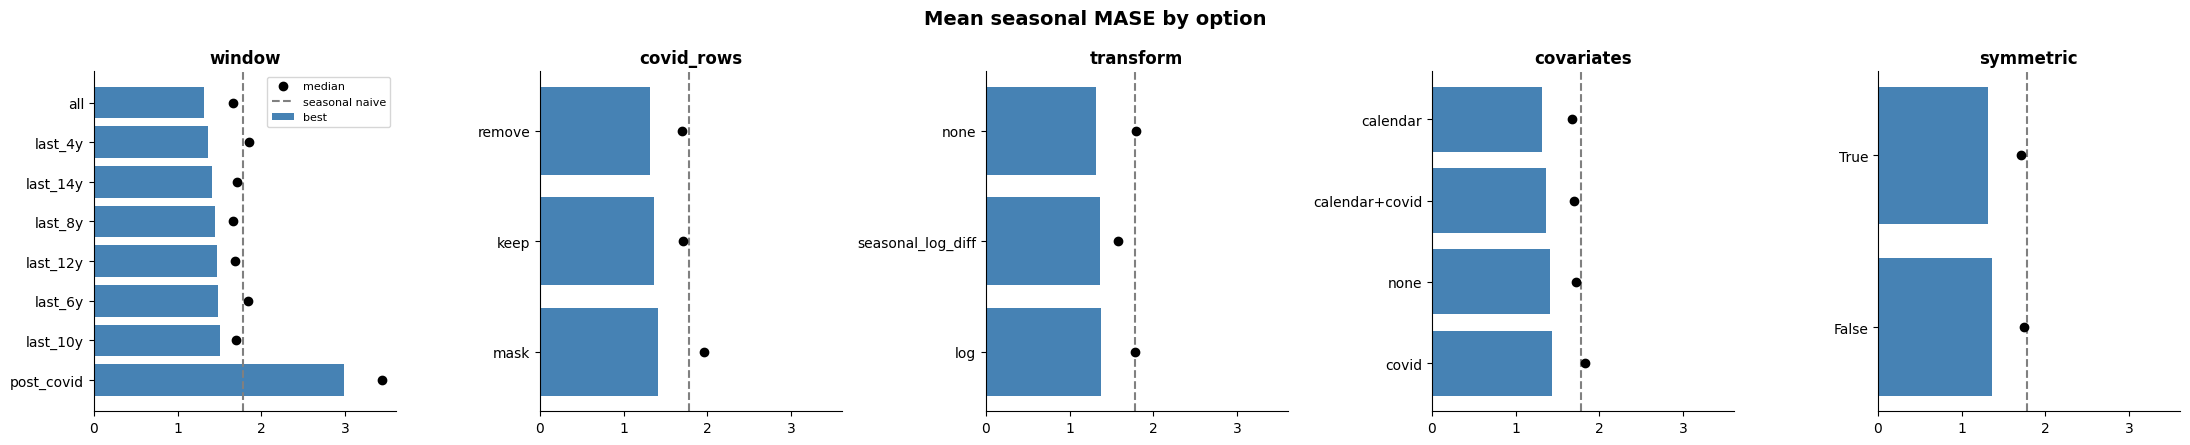

In [13]:
fig, axes = plt.subplots(1, len(PARAM_KEYS), figsize=(22, 4.5), sharex=True)
for ax, key in zip(axes, PARAM_KEYS):
    stats = ranked.groupby(key, sort=False)['MASE_mean'].agg(['min', 'median'])
    labels = [str(v) for v in stats.index]
    ax.barh(labels, stats['min'], color='steelblue', label='best')
    ax.scatter(stats['median'], labels, color='black', zorder=3, label='median')
    ax.axvline(BASELINE_MASE, color='grey', linestyle='--', label='seasonal naive')
    ax.set_title(key, fontweight='bold')
    ax.invert_yaxis()
    sns.despine(ax=ax)
axes[0].legend(fontsize=8)
fig.suptitle('Mean seasonal MASE by option', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Top 10 Configurations — Validation Forecasts

The same view as notebooks 5, 7 and 8: the ten best configurations (by mean seasonal MASE), each
with the last 24 training months, the actual validation year and the median forecast of the
latest origin, now with the **80% interval** (0.1–0.9 quantiles) shaded.

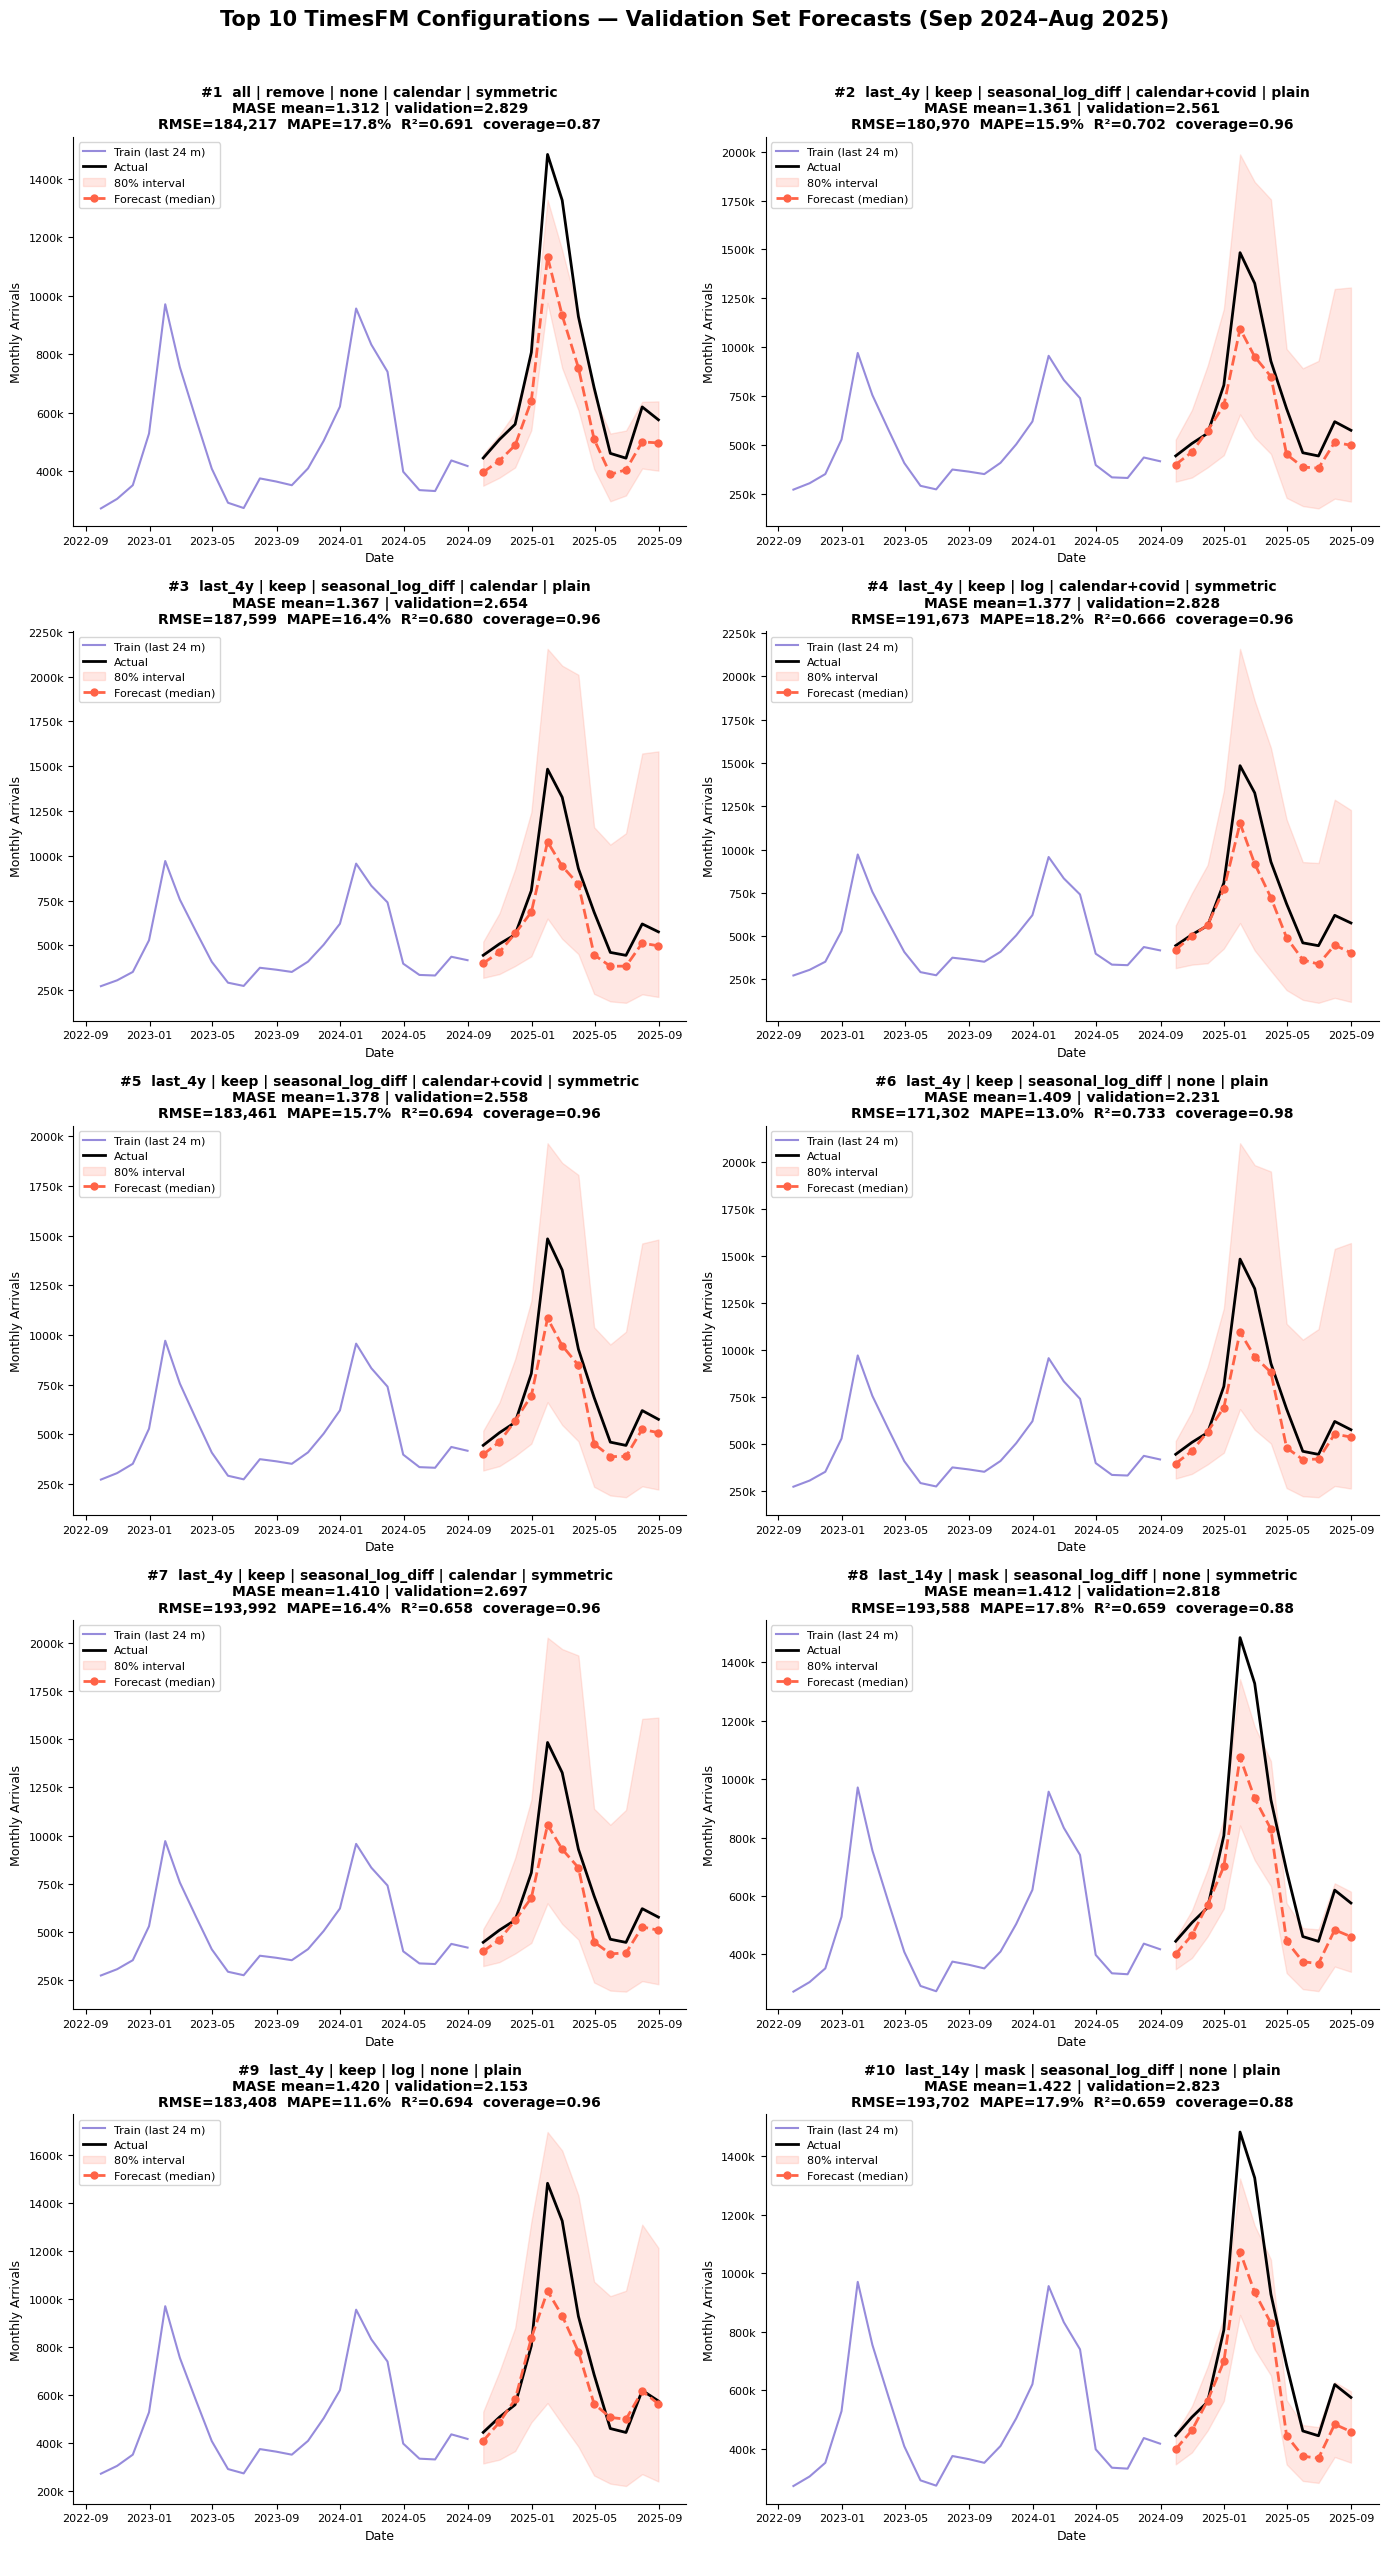

In [14]:
top10 = ranked.head(10)
train_plot = train_series.iloc[-24:]

fig, axes = plt.subplots(5, 2, figsize=(14, 26))
fig.suptitle(
    f'Top 10 TimesFM Configurations — Validation Set Forecasts '
    f'({val_series.index[0]:%b %Y}–{val_series.index[-1]:%b %Y})',
    fontsize=15,
    fontweight='bold',
)

for i, (ax, (_, row)) in enumerate(zip(axes.flat, top10.iterrows())):
    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Train (last 24 m)',
        linewidth=1.5,
        color='slateblue',
        alpha=0.7,
    )
    ax.plot(
        val_series.index, val_series.values, label='Actual', linewidth=2, color='black'
    )
    ax.fill_between(
        val_series.index,
        row['low'],
        row['high'],
        color='tomato',
        alpha=0.15,
        label='80% interval',
    )
    ax.plot(
        val_series.index,
        row['prediction'],
        label='Forecast (median)',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )
    ax.set_title(
        f'#{i + 1}  {Config(*row[PARAM_KEYS]).label}\n'
        f'MASE mean={row["MASE_mean"]:.3f} | validation={row["MASE"]:.3f}\n'
        f'RMSE={row["RMSE"]:,.0f}  MAPE={row["MAPE"]:.1f}%  R²={row["R2"]:.3f}  '
        f'coverage={row["coverage_80_mean"]:.2f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Monthly Arrivals', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

for ax in axes.flat[len(top10) :]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Heatmaps of the Combinations

As in notebooks 5, 7 and 8, each cell summarizes all configurations that share the two choices on
its axes with the **p95 of the mean seasonal MASE** (the value only the best 5% of the cell beat),
with the number of configurations under it. The grid is small (about 5–60 configurations per
cell), so the p95 is close to the best value of each cell.

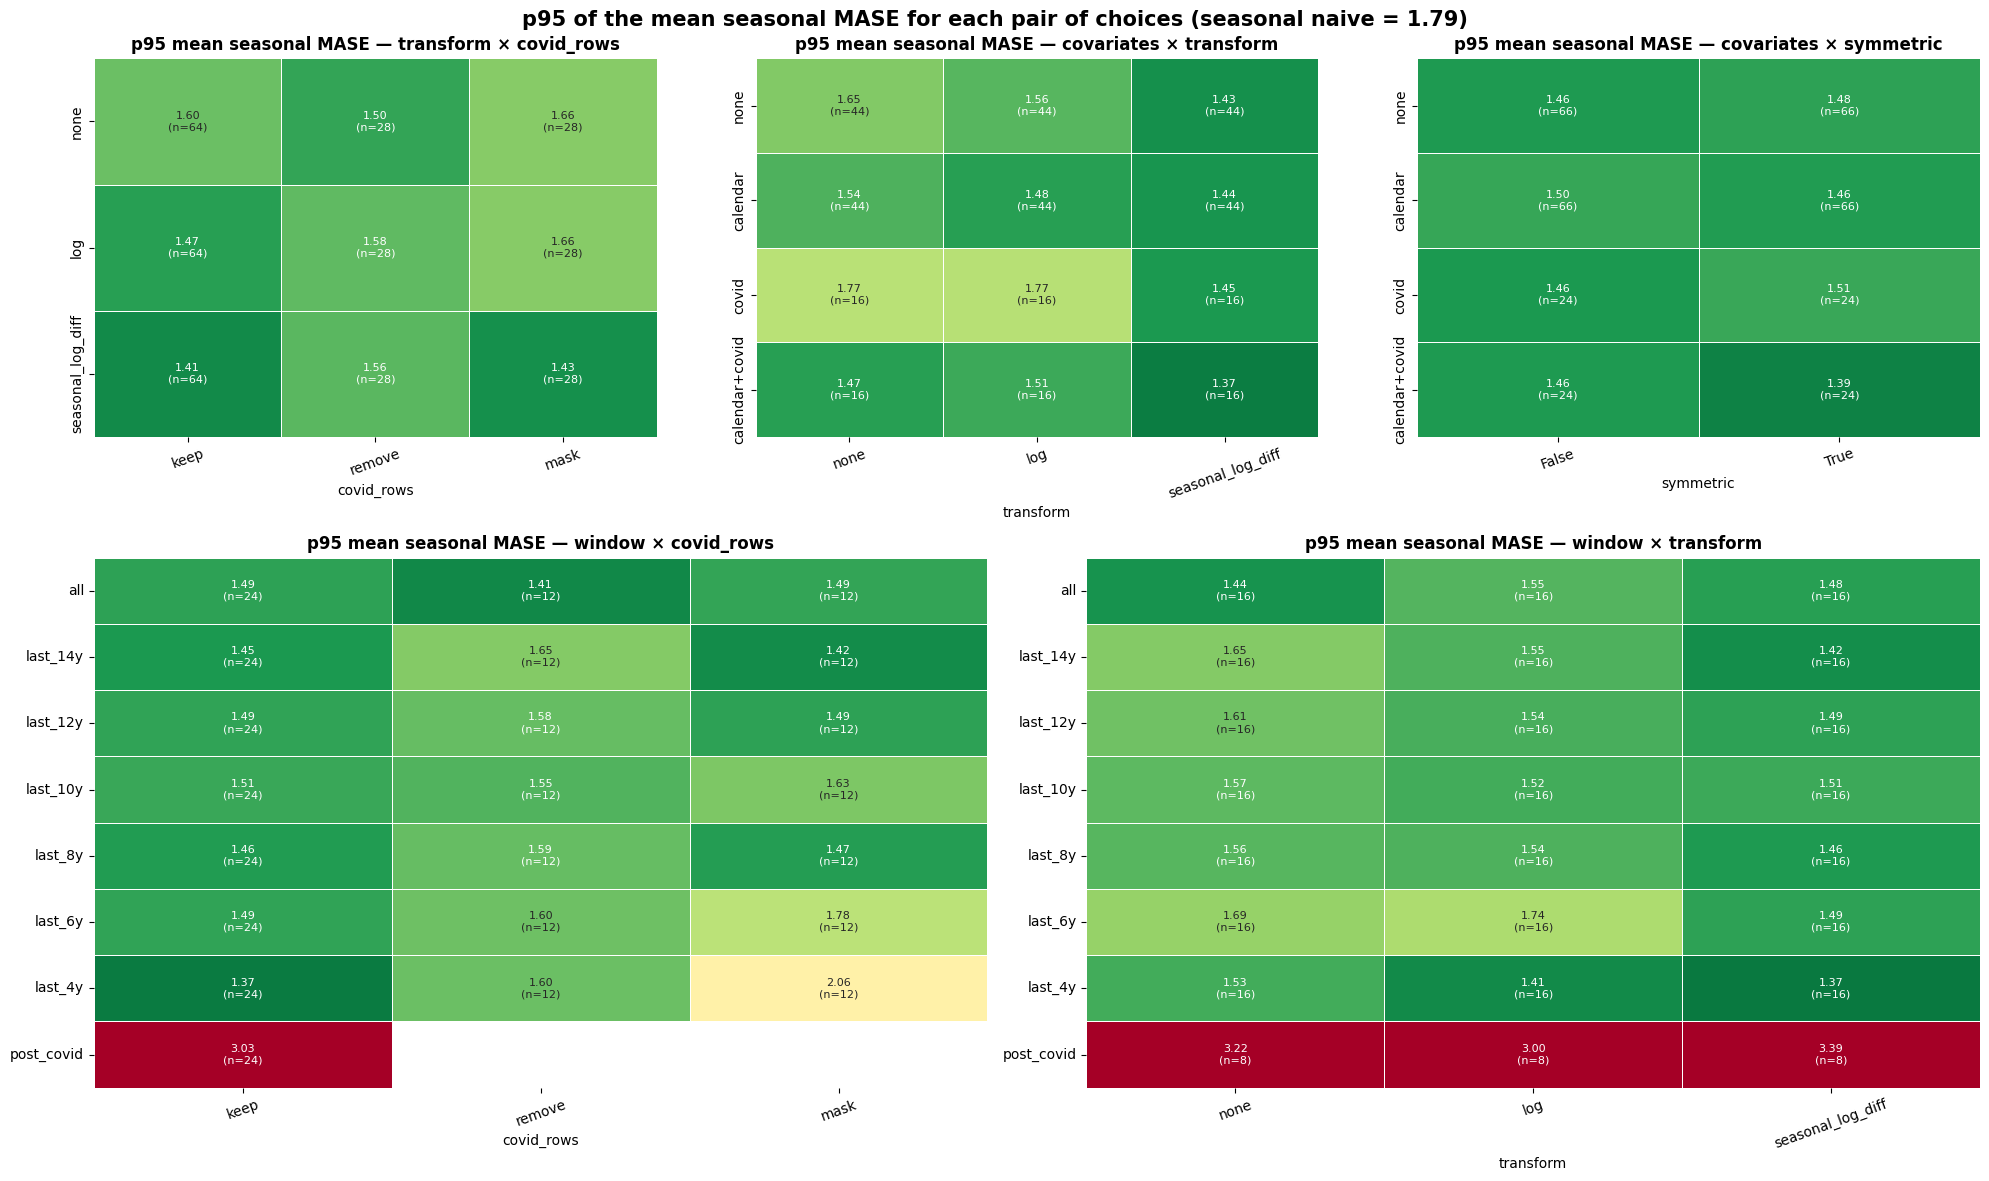

In [15]:
ORDERS = {
    'window': list(WINDOWS),
    'covid_rows': COVID_ROWS,
    'transform': TARGET_TRANSFORMS,
    'covariates': COVARIATES,
    'symmetric': [False, True],
}
HEATMAP_LAYOUT = [
    # (rows, columns, grid position)
    ('transform', 'covid_rows', (0, slice(0, 2))),
    ('covariates', 'transform', (0, slice(2, 4))),
    ('covariates', 'symmetric', (0, slice(4, 6))),
    ('window', 'covid_rows', (1, slice(0, 3))),
    ('window', 'transform', (1, slice(3, 6))),
]
MASE_LABEL_CAP = 10
P95_QUANTILE = 0.05  # p95: the value only the best 5% of a cell's configurations beat


def p95(values):
    return values.quantile(P95_QUANTILE)


def mase_label(value, count):
    if pd.isna(value):
        return ''
    shown = f'>{MASE_LABEL_CAP}' if value > MASE_LABEL_CAP else f'{value:.2f}'
    return f'{shown}\n(n={int(count)})'


def p95_mase_pivot(rows, columns):
    """p95 of the mean seasonal MASE per cell, and the configurations per cell."""
    pivot, counts = (
        ranked.pivot_table(
            index=rows, columns=columns, values='MASE_mean', aggfunc=aggfunc
        ).reindex(
            index=[v for v in ORDERS[rows] if v in ranked[rows].unique()],
            columns=[v for v in ORDERS[columns] if v in ranked[columns].unique()],
        )
        for aggfunc in (p95, 'count')
    )
    labels = pd.DataFrame(
        [
            [mase_label(v, n) for v, n in zip(values, ns)]
            for values, ns in zip(pivot.to_numpy(), counts.to_numpy())
        ],
        index=pivot.index,
        columns=pivot.columns,
    )
    return pivot, labels


fig = plt.figure(figsize=(20, 12))
grid = fig.add_gridspec(2, 6, height_ratios=[1, 1.4])
for rows, columns, (r, c) in HEATMAP_LAYOUT:
    ax = fig.add_subplot(grid[r, c])
    pivot, labels = p95_mase_pivot(rows, columns)
    sns.heatmap(
        pivot,
        annot=labels,
        fmt='',
        annot_kws={'fontsize': 8},
        cmap='RdYlGn_r',
        vmin=ranked['MASE_mean'].min(),
        vmax=BASELINE_MASE * 1.5,
        linewidths=0.4,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f'p95 mean seasonal MASE — {rows} × {columns}', fontweight='bold')
    ax.set_xlabel(columns)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=20)
fig.suptitle(
    'p95 of the mean seasonal MASE for each pair of choices '
    f'(seasonal naive = {BASELINE_MASE:.2f})',
    fontsize=15,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 10. TimesFM vs the Trained Models

The best run of notebooks 5 (SARIMAX), 7 (local ML) and 8 (global ML), read from their MLflow
experiments, next to the best and the out-of-the-box TimesFM configurations. All are scored on the
same total, at the same origins, with the same seasonal MASE. A notebook whose runs are missing,
or were logged with other origins, is reported instead of compared.

In [16]:
TRAINED_EXPERIMENTS = {
    'SARIMAX (notebook 5)': ('Brazil Tourism Forecasting ARIMA', 'mase'),
    'Local ML (notebook 7)': ('Brazil Tourism Forecasting ML', 'MASE'),
    'Global ML (notebook 8)': ('Brazil Tourism Forecasting ML Global', 'MASE'),
}


def best_run(experiment_name, prefix):
    found = mlflow.get_experiment_by_name(experiment_name)
    if found is None:
        return None
    finished = "attributes.status = 'FINISHED' and params.eval_split = 'validation'"
    runs = client.search_runs(
        [found.experiment_id],
        filter_string=finished,
        order_by=[f'metrics.{prefix}_mean ASC'],
        max_results=1,
    )
    return runs[0] if runs else None


def row_of(approach, configuration, source):
    return {
        'approach': approach,
        'configuration': configuration,
        'MASE_mean': source['MASE_mean'],
        'MASE_worst': source['MASE_worst'],
        'MASE (validation year)': source['MASE'],
        'RMSE (validation year)': source['RMSE'],
        'MAPE (validation year)': source['MAPE'],
    }


comparison = []
for approach, (experiment_name, prefix) in TRAINED_EXPERIMENTS.items():
    run = best_run(experiment_name, prefix)
    if run is None:
        print(f'{approach}: no runs in "{experiment_name}"')
        continue
    logged_origins = sorted(run.data.params.get('origins', '').split(', '))
    if logged_origins != sorted(ORIGIN_LABELS.split(', ')):
        print(
            f'{approach}: logged with other origins ({run.data.params.get("origins")})'
        )
        continue
    m = run.data.metrics
    comparison.append(
        row_of(
            approach,
            run.info.run_name,
            {
                'MASE_mean': m.get(f'{prefix}_mean'),
                'MASE_worst': m.get(f'{prefix}_worst'),
                'MASE': m.get(prefix),
                'RMSE': m.get('rmse', m.get('RMSE')),
                'MAPE': m.get('mape', m.get('MAPE')),
            },
        )
    )
best = ranked.iloc[0]
comparison.append(
    row_of('TimesFM, best context', Config(*best[PARAM_KEYS]).label, best)
)
comparison.append(
    row_of('TimesFM, out of the box', DEFAULT_CONFIG.label, ranked.loc[default_rank])
)
comparison.append(
    row_of(
        'Seasonal naive',
        'same month last year',
        baselines.loc['seasonal_naive'],
    )
)
pd.DataFrame(comparison).set_index('approach').round(3)

,configuration,MASE_mean,MASE_worst,MASE (validation year),RMSE (validation year),MAPE (validation year)
approach,,,,,,
SARIMAX (notebook 5),"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.992,1.258,1.258,103693.084,7.302
Local ML (notebook 7),xgboost | seasonal_log_diff | last_4y | keep |...,0.982,1.179,1.179,80115.966,7.788
Global ML (notebook 8),xgboost | seasonal_log_diff | last_6y | keep |...,1.101,1.563,1.563,125101.593,9.051
"TimesFM, best context",all | remove | none | calendar | symmetric,1.312,2.829,2.829,184216.923,17.815
"TimesFM, out of the box",all | keep | none | none | plain,1.715,3.949,3.949,262799.177,24.614
Seasonal naive,same month last year,1.786,4.024,4.024,255353.116,26.478


## 11. Save the Best Configuration's Validation Forecasts

The ensembling notebook (10) combines the best configuration of every approach, so it needs
their **forecasts**, not only their metrics. The best configuration of this notebook (rank 1 by
mean seasonal MASE) is re-run at every validation origin (read from the grid results, nothing is recomputed), and its forecasts
are logged as the artifact `validation_forecasts.csv` of a run tagged
`role = best_validation_forecasts` in this notebook's experiment:

| Column | Content |
|---|---|
| `origin` | the validation origin (`YYYY-MM`) |
| `date` | the forecast month |
| `actual` | the actual total arrivals |
| `forecast` | the forecast of the total (median), plus `low` and `high`, the 0.1 and 0.9 quantiles |

The mean seasonal MASE of these forecasts must match the ranking, which is checked before
logging. The run has no `eval_split` parameter, so the comparison queries of the other
notebooks do not pick it up as a grid run.

In [17]:
best = ranked.iloc[0]
best_config = Config(*best[PARAM_KEYS])
origin_results = [
    by_task[effective(best_config, origin), origin]
    for origin in config_origins(best_config)
]
best_forecasts = pd.concat(
    [
        pd.DataFrame({
            'origin': origin_label(r['origin']),
            'date': val_actual_at(r['origin']).index,
            'actual': val_actual_at(r['origin']).to_numpy(),
            'forecast': r['prediction'],
            'low': r['low'],
            'high': r['high'],
        })
        for r in origin_results
    ],
    ignore_index=True,
)
mase_mean = float(np.mean([r['MASE'] for r in origin_results]))
assert np.isclose(mase_mean, best['MASE_mean']), (mase_mean, best['MASE_mean'])


def log_validation_forecasts(approach, configuration, forecasts, mase_mean):
    """Log the best configuration's forecasts at every origin as an MLflow artifact."""
    with mlflow.start_run(
        run_name=f'BEST validation forecasts | {configuration}'[:250]
    ):
        mlflow.set_tags({'role': 'best_validation_forecasts', 'approach': approach})
        mlflow.log_params({
            'configuration': configuration[:500],
            'origins': ', '.join(sorted(forecasts['origin'].unique())),
            'horizon': HORIZON,
        })
        mlflow.log_metric('MASE_mean', mase_mean)
        mlflow.log_text(forecasts.to_csv(index=False), 'validation_forecasts.csv')
    print(f'{approach}: logged {len(forecasts)} forecasts of {configuration}')


log_validation_forecasts('TimesFM', best_config.label, best_forecasts, mase_mean)

TimesFM: logged 48 forecasts of all | remove | none | calendar | symmetric


## Reading the Results

| Question | Where |
|---|---|
| Does TimesFM beat the seasonal naive without any training? | `beats_seasonal_naive`, section 8 |
| How much do the context choices add to the model out of the box? | Rank of the out-of-the-box configuration, section 8 and 10 |
| How much history should the model read? | *Effect of each choice* (`window`) and heatmap *window × covid_rows* |
| Is it better to keep, remove or mask the pandemic? | Heatmap *transform × covid_rows* |
| Level, log level or growth rate? | Heatmap *transform × covid_rows* and *window × transform* |
| Do calendar terms or COVID flags help? | Heatmap *covariates × transform* |
| Are the intervals trustworthy? | `coverage_80_mean` (ideal 0.8) and the shaded bands of the top 10 |
| Does a zero-shot foundation model beat the trained models? | Section 10 |

Things to keep in mind:

- **Selection on validation data.** The best of about 360 context configurations is optimistic,
  although much less than the thousands of trained configurations of notebooks 5 and 7. The
  unbiased score comes from the test year in the final notebook.
- **Pretraining data.** TimesFM was pretrained on a large public corpus that may include tourism
  series. Zero-shot results on the validation years are not a sign of leakage from this project,
  but part of the pattern knowledge comes from outside it.
- **License.** TimesFM 3.0 weights are for research and non-commercial use only.